<a href="https://colab.research.google.com/github/blade-git/bitcoin-price-prediction/blob/main/%5BPrivate_2%EC%9C%84%2C_Public_5%EC%9C%84%5D_LSTM_%EB%AA%A8%EB%8D%B8_%EA%B8%B0%EB%B0%98_%EB%B9%84%ED%8A%B8%EC%BD%94%EC%9D%B8_%EA%B0%80%EA%B2%A9_%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 코드를 실행하기 위한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import random
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 시드 값 설정 : 재현성을 위해 시드 값을 42로 설정
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

In [ ]:
# 데이터 불러오기
train = pd.read_csv('/content/drive/MyDrive/train.csv')
submission = pd.read_csv('/content/drive/MyDrive/sample_submission.csv')

In [ ]:
train

,Time,Open,High,Low,Close,Volume,quote_av,trades,tb_base_av,tb_quote_av
0,2018-01-01 00:00:00,137.16,137.16,134.00,135.29,448.356199,60938.151102,5233,233.521921,31742.292816
1,2018-01-01 01:00:00,135.29,135.96,131.55,132.03,388.697006,51978.180847,4539,185.840403,24854.840552
2,2018-01-01 02:00:00,132.03,134.18,132.00,133.30,434.064572,57684.143554,4892,197.237935,26215.165628
3,2018-01-01 03:00:00,133.30,136.11,132.90,134.10,425.087030,57011.962962,4794,142.918407,19172.428559
4,2018-01-01 04:00:00,134.35,136.23,133.22,136.01,345.807329,46674.215567,4568,177.957635,24022.525818
...,...,...,...,...,...,...,...,...,...,...
54569,2024-03-28 19:00:00,705.49,709.13,704.82,707.98,1233.569390,871989.082208,82625,621.745210,439518.571710
54570,2024-03-28 20:00:00,707.98,708.75,706.19,706.73,754.731310,533942.900430,59964,357.794750,253144.400614
54571,2024-03-28 21:00:00,706.73,709.06,706.54,707.81,603.941410,427345.556770,45225,323.370640,228831.685668
54572,2024-03-28 22:00:00,707.81,708.81,705.41,708.47,789.633720,558802.030425,50729,391.559820,277113.932578


# 데이터 전처리
데이터를 로드하고 DataFrame의 'Time'열에 있는 값을 datetime 형식으로 변환하고 Min-Max 정규화를 사용하여 LSTM 모델의 학습을 원활하게 하기 위해서 수행하였습니다.
그리고 주어진 데이터로부터 시계열 데이터셋을 생성하는 함수를 정의하였습니다.

In [ ]:
# 시간 형식 변환
train['Time'] = pd.to_datetime(train['Time'])
train.set_index('Time', inplace=True)

In [ ]:
# Min-Max 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(train['Close'].values.reshape(-1, 1))

In [ ]:
# 데이터셋 생성
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

# 파라미터 지정
'time_step'을 1로 설정하여 1시간의 데이터를 기반으로 다음 값을 예측하였습니다.

In [ ]:
# 파라미터 설정
time_step = 1
X, y = create_dataset(scaled_data, time_step)

# 데이터셋 분할 및 날짜 인덱스 생성
훈련용 데이터셋만 이용해서 학습하면 훈련용 데이터에만 최적화되어 새로운 데이터에 대해서 올바르게 예측하지 못하는 과적합 현상이 생길 수 있기 때문에 데이터셋의 80%를 훈련용으로, 나머지 20%는 테스트용 데이터셋으로 분리하는 작업을 거치고, 시계열 시각화를 위해 날짜 인덱스를 생성하였습니다.

In [ ]:
# 데이터셋 분할 (Train 80%, Test 20%)
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

In [ ]:
# 날짜 인덱스 생성 : 시각화를 위해 인덱스 생성
train_dates = train.index[:train_size]
test_dates = train.index[train_size:len(X)]

# LSTM 모델 구축
모델을 잘 구축하기 위해서 모델 입력 형식에 맞게 데이터를 변환하고, RMSE를 계산하여 모델의 성능을 평가했습니다.

In [ ]:
# LSTM 모델 입력 형식에 맞게 데이터를 변환
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
# LSTM 모델 구축
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

# 조기 종료 콜백
early_stop = EarlyStopping(monitor='val_loss', patience=10)

# 모델 훈련
model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/20
1365/1365 [==============================] - 13s 6ms/step - loss: 0.0020 - val_loss: 7.8947e-06
Epoch 2/20
1365/1365 [==============================] - 8s 6ms/step - loss: 1.1883e-05 - val_loss: 8.0872e-06
Epoch 3/20
1365/1365 [==============================] - 7s 5ms/step - loss: 1.2660e-05 - val_loss: 2.6009e-05
Epoch 4/20
1365/1365 [==============================] - 8s 6ms/step - loss: 1.4904e-05 - val_loss: 1.7534e-05
Epoch 5/20
1365/1365 [==============================] - 7s 5ms/step - loss: 1.5200e-05 - val_loss: 7.6193e-06
Epoch 6/20
1365/1365 [==============================] - 8s 6ms/step - loss: 1.4469e-05 - val_loss: 8.4284e-06
Epoch 7/20
1365/1365 [==============================] - 8s 6ms/step - loss: 1.5468e-05 - val_loss: 1.2329e-05
Epoch 8/20
1365/1365 [==============================] - 9s 6ms/step - loss: 1.4568e-05 - val_loss: 4.2932e-05
Epoch 9/20
1365/1365 [==============================] - 7s 5ms/step - loss: 1.4919e-05 - val_loss: 7.6921e-06
Epoch 10/20
1

In [ ]:
# 예측 : 훈련 데이터와 테스트 데이터에 대해 예측
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

342/342 [==============================] - 1s 2ms/step


In [ ]:
# 데이터 역변환 : 예측값과 실제값을 원래 스케일로 복원
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train = scaler.inverse_transform([y_train])
y_test = scaler.inverse_transform([y_test])

In [ ]:
# RMSE 계산
train_score = np.sqrt(mean_squared_error(y_train[0], train_predict[:, 0]))
test_score = np.sqrt(mean_squared_error(y_test[0], test_predict[:, 0]))
print(f'Train RMSE: {train_score:.2f}')
print(f'Test RMSE: {test_score:.2f}')

Train RMSE: 2.25
Test RMSE: 1.95


# LSTM 모델 시각화


In [ ]:
# 그래프 크기 조정
plt.figure(figsize=(20, 10))

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

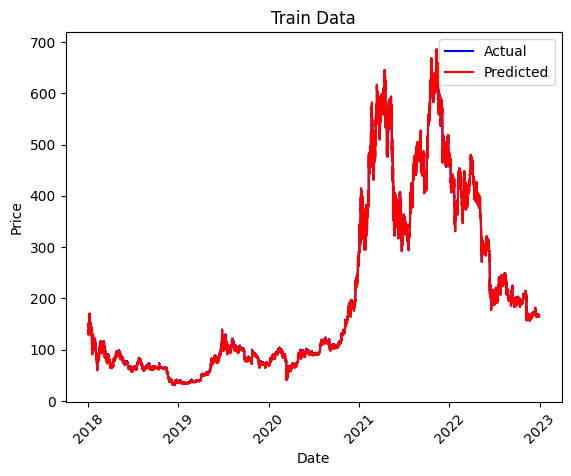

In [ ]:
# 훈련 데이터 시각화
from matplotlib.dates import DateFormatter
plt.subplot(1, 1, 1)
plt.plot(train_dates, y_train[0], label='Actual', color = 'Blue')
plt.plot(train_dates, train_predict, label='Predicted', color = 'Red')
plt.title('Train Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y'))

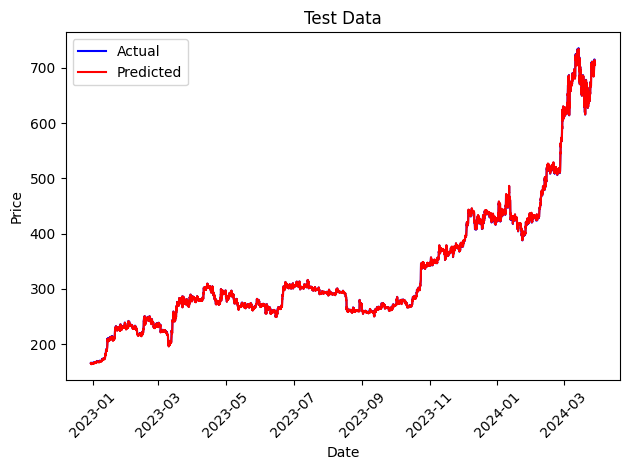

In [ ]:
# 테스트 데이터 시각화
plt.subplot(1, 1, 1)
plt.plot(test_dates, y_test[0], label='Actual', color = 'Blue')
plt.plot(test_dates, test_predict, label='Predicted', color = 'Red')
plt.title('Test Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

# 미래 데이터 예측 및 결과 저장
훈련된 LSTM 모델을 사용하여 미래 데이터를 예측하고, 예측 결과를 파일로 저장하였습니다.

In [ ]:
# 예측할 미래 데이터 준비
last_1_days = scaled_data[-time_step:]
X_predict = last_1_days.reshape(1, time_step, 1)

In [ ]:
# 예측 수행
future_predictions = []
for _ in range(len(submission)):
    pred = model.predict(X_predict)
    future_predictions.append(pred[0, 0])
    pred = pred.reshape(1, 1, 1)
    X_predict = np.append(X_predict[:, 1:, :], pred, axis=1).reshape(1, time_step, 1)

1/1 [==============================] - 0s 22ms/step


In [ ]:
# 스케일링 복원
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

In [ ]:
# 결과 저장
submission['Close'] = future_predictions
submission.to_csv('sample_submission.csv', index=False)

In [ ]:
# sample_submission.csv 파일을 읽어옵니다.
submission_data = pd.read_csv('/content/sample_submission.csv')

In [ ]:
submission_data

,Time,Close
0,2024-03-29 00:00:00,706.91920
1,2024-03-29 01:00:00,706.05450
2,2024-03-29 02:00:00,705.20526
3,2024-03-29 03:00:00,704.37150
4,2024-03-29 04:00:00,703.55260
...,...,...
1507,2024-05-30 19:00:00,648.67554
1508,2024-05-30 20:00:00,648.67554
1509,2024-05-30 21:00:00,648.67554
1510,2024-05-30 22:00:00,648.67554
